# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [6]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [7]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [8]:
data_df.sample(5)

,title,text,label
1254,Phạt 500 triệu đồng đối với hành vi nhập khẩu ...,Theo đó thực hiện ý kiến chỉ đạo của Cục Quản ...,0
11283,Luận về học thật thi thật nhân tài thật,Đánh giá gia tài của Bộ Trưởng Giáo Dục và Đào...,1
9090,Cuộc chuyển tiếp từ độc tài toàn trị đến dân c...,Mới đây cuộc đàm phán giữa tân chính phủ Venez...,1
2049,Cảnh sát bắn chết bạn gái khi dạy cách lau súng,MỹPhó cảnh sát trưởng hạt Marion Leslie Boilea...,0
9183,Cưỡng chế vườn rau Lộc Hưng - Tp HCM sẽ có thê...,* Khu vực vườn rau Lộc Hưng 9 P.6 Q.Tân Bình) ...,1


**Mô tả của dữ liệu**

In [9]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [10]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của DataFrame và danh sách các tên cột**

In [11]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [12]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [13]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [14]:
data_df['title'].isnull().sum()

0

In [15]:
data_df['text'].isnull().sum()

0

In [16]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [17]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [18]:
open_object_dtype(data_df['title'])

{str}

In [19]:
open_object_dtype(data_df['text'])

{str}

In [20]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [21]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [22]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


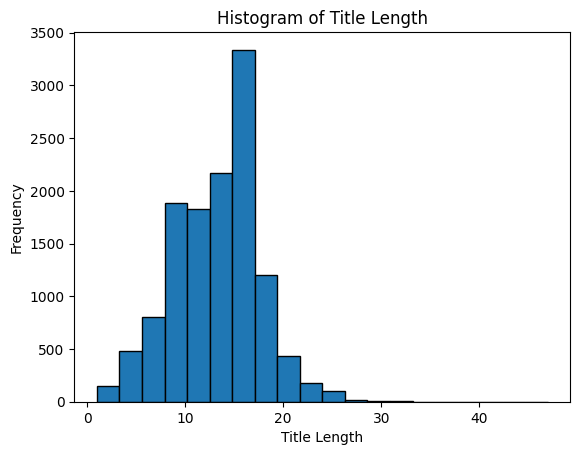

In [23]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

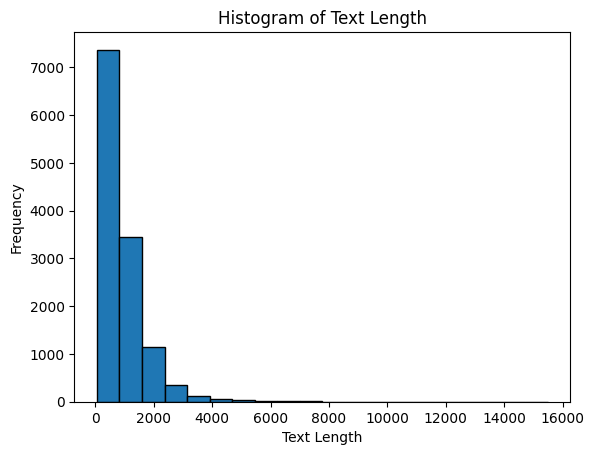

In [24]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

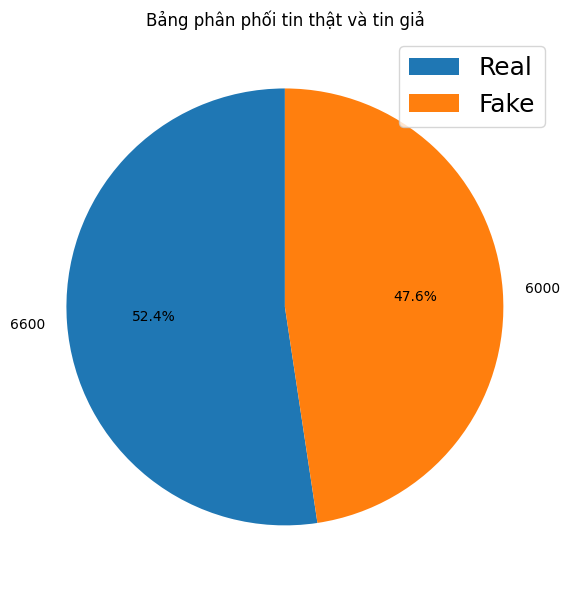

In [25]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [26]:
len_title_sum=0

for i in data_df['title']:
    len_title_sum+=len(i)

avg_title=len_title_sum/data_df['title'].count()

avg_title

57.98587301587302

**Độ dài lớn nhất của tiêu đề**

In [27]:
max_title_len=0

for i in data_df['title']:
    if len(i)>max_title_len:
        max_title_len=len(i)

max_title_len

202

**Độ dài nhỏ nhất của tiêu đề**

In [28]:
min_title_len=max_title_len

for i in data_df['title']:
    if len(i) < min_title_len:
        min_title_len=len(i)

min_title_len

3

**Chiều dài trung bình text của 1 tin tức**

In [29]:
len_text_sum=0

for i in data_df['text']:
    len_text_sum+=len(i)

avg_text=len_text_sum/data_df['text'].count()

avg_text

4070.9562698412697

**Độ dài lớn nhất của text**

In [30]:
max_text_len=0

for i in data_df['text']:
    if len(i)>max_text_len:
        max_text_len=len(i)

max_text_len

68695

**Độ dài nhỏ nhất của text**

In [31]:
min_text_len=max_text_len

for i in data_df['text']:
    if len(i) < min_text_len:
        min_text_len=len(i)

min_text_len

300

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [32]:
from pyvi import ViTokenizer

In [33]:
def remove_special_characters(text):
    ## Remove punctuations
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…"""), ' ', text)
    text = text.replace('؛',"", )
    text = re.sub('https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('[^\w\s]', ' ', text) 
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text =  " ".join(text.split())
    return text.strip()

#delete stop words
def remove_stopwords(text):
    clean_tokens = ' '.join([word for word in text.split() if word not in stopwords])
    return clean_tokens

def preprocess_nostop(text):
    text = remove_special_characters(text)
    return text

In [34]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [35]:
data_df['article'] = ' |title| '+ data_df["title"] +' |text| '+  data_df["text"] 

In [36]:
data_df.head(1)

,title,text,label,title_length,text_length,article
0,Cấm biển di dân khỏi vùng nguy hiểm từ Quảng N...,Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,0,14,1448,|title| Cấm biển di dân khỏi vùng nguy hiểm t...


**Áp dụng các xử lý dữ liệu**

In [37]:
data_df['Compound_Content'] = data_df['article'].apply(tokenizerVN)

In [38]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(preprocess_nostop)

In [39]:
data_df.head(1)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
0,Cấm biển di dân khỏi vùng nguy hiểm từ Quảng N...,Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,0,14,1448,|title| Cấm biển di dân khỏi vùng nguy hiểm t...,| title | Cấm biển di_dân khỏi vùng nguy_hiểm ...,title cấm biển di_dân khỏi vùng nguy_hiểm từ q...


# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [40]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()


**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [41]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [42]:
# model_vector_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
# model_RFC_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")

In [43]:
model_vector_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_vectorizer_TF.joblib")
# model_RFC_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")

In [44]:
# model_vector_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
# model_RFC_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")

In [45]:
# model_vector_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
# model_RFC_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [46]:
vectorizerCV = CountVectorizer(
    stop_words = stopwords,
    tokenizer = tokenize,
)

In [47]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [48]:
vectorizerTF = TfidfVectorizer(max_features=50000,
                               tokenizer=tokenize,
                                stop_words=stopwords,
                                min_df=0.002, max_df=0.5, 
                                use_idf=True, ngram_range=(1,3))

In [49]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [50]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [51]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=20
)

In [52]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [53]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [54]:
documents = [TaggedDocument(doc.split(), [i]) for i, doc in enumerate(X_train)]

In [55]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [56]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [57]:
# joblib.dump(vectorizerCV, model_vector_CV)
joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Vector/Vietnamese\\Vietnamese_vectorizer_TF.joblib']

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [58]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [59]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [60]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [61]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [62]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [63]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [64]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [65]:
def evaluate_model(y_true, y_pred, name_model, save=False):
    
    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }

    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation_metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/VietNamese", f"Vietnamese_Evaluate_{name_model}.csv")
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

### CountVectorizer

0.9726984126984127
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1586
           1       0.98      0.97      0.97      1564

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



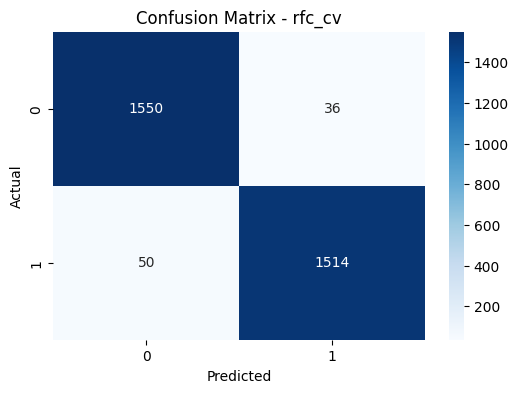

In [66]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv", save=True)

### TfidfVectorizer 

0.979047619047619
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1586
           1       0.98      0.98      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



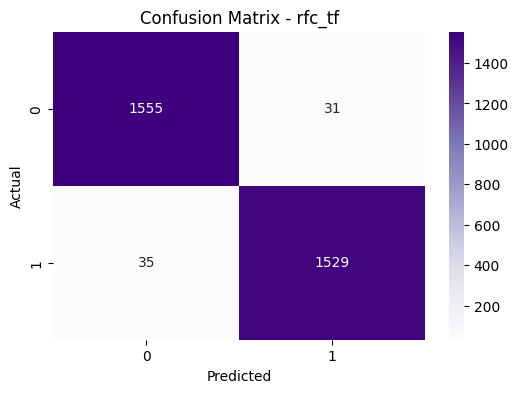

In [67]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf", save=True)

### Word2Vec

0.9717460317460317
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1586
           1       0.98      0.96      0.97      1564

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



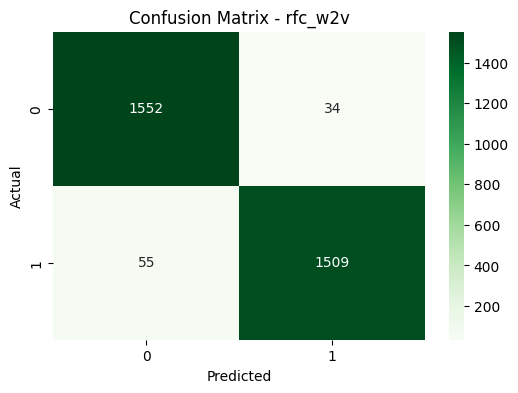

In [68]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v", save=True)


## Doc2Vec

0.9631746031746031
-------------------

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1586
           1       0.96      0.96      0.96      1564

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



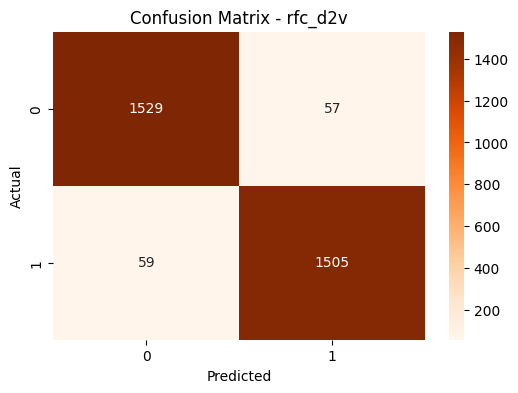

In [69]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v", save=True)

*Save model RFC*

In [70]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [71]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.953015873015873
-------------------

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1586
           1       0.95      0.95      0.95      1564

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



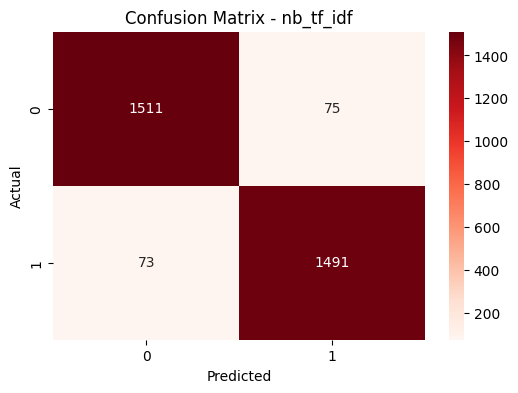

In [72]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf_idf")

## DecisionTree

In [73]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.9244444444444444
-------------------

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1586
           1       0.94      0.91      0.92      1564

    accuracy                           0.92      3150
   macro avg       0.92      0.92      0.92      3150
weighted avg       0.92      0.92      0.92      3150

-------------------



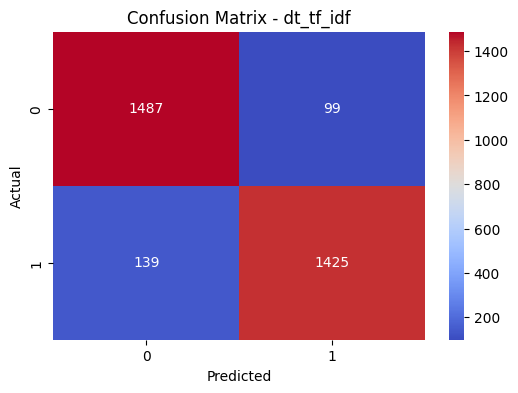

In [74]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf_idf")

## RandomForest

In [75]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.979047619047619
-------------------

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1586
           1       0.98      0.98      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



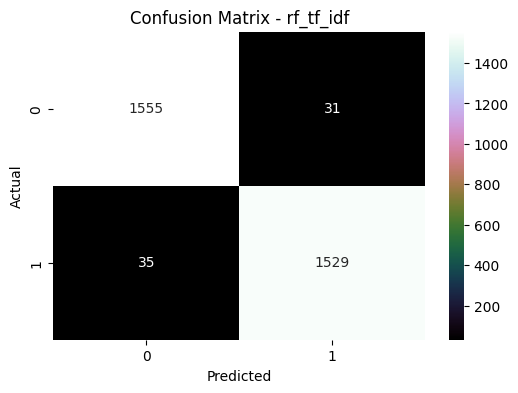

In [76]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf_idf")

## SVM

In [77]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9844444444444445
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1586
           1       0.99      0.98      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



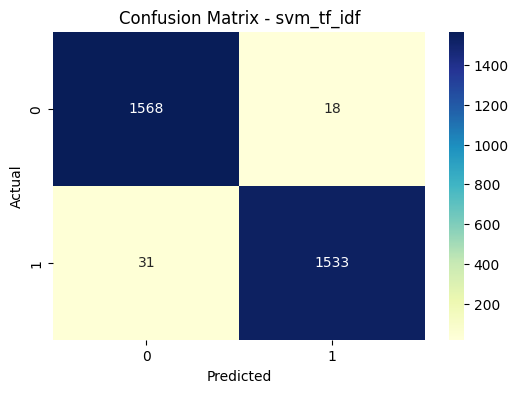

In [78]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf_idf")

In [79]:
model_SVM_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/Vietnamese\\Vietnamese_SVM_model_TF.joblib']

## LogisticRegression

In [80]:
lr_model = LogisticRegression()
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)

0.9771428571428571
-------------------

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1586
           1       0.99      0.97      0.98      1564

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



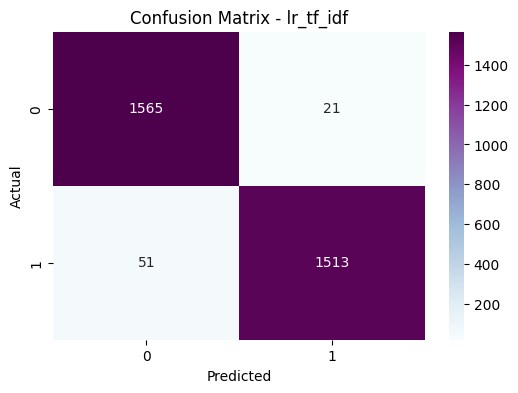

In [81]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf_idf")

## GradientBoostingClassifier

In [82]:
gbc_model = GradientBoostingClassifier(random_state=0)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.9695238095238096
-------------------

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1586
           1       0.98      0.96      0.97      1564

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



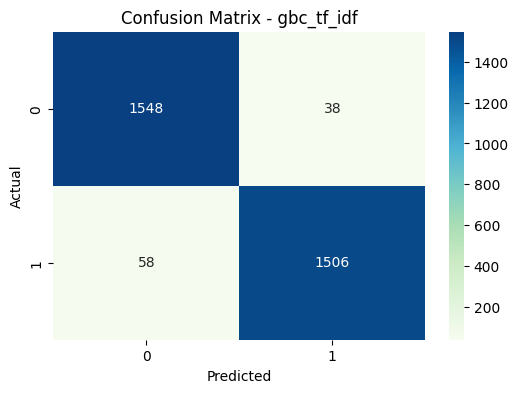

In [83]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf_idf")